<a href="https://colab.research.google.com/github/Krisnaaassss/heart-disease-classification-bayesian-soft-voting/blob/main/Heart_Disease_Classification_Bayesian_Soft_Voting_All_Datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Setup and Configuration


## 1.1 Library Installation and Imports


In [ ]:
!pip install xgboost lightgbm imbalanced-learn shap scikit-optimize -q

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.model_selection import (StratifiedKFold, cross_validate,
                                      GridSearchCV, RandomizedSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (make_scorer, precision_score, recall_score, f1_score,
                             accuracy_score, roc_auc_score)
from sklearn.ensemble import VotingClassifier
from sklearn.base import BaseEstimator, ClassifierMixin, clone

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
import lightgbm as lgb
import shap

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from skopt import BayesSearchCV, gp_minimize
from skopt.space import Real, Integer, Categorical

print('Libraries loaded successfully.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.6 MB/s eta 0:00:00
Libraries loaded successfully.


## 1.2 Global Configuration


In [ ]:
RANDOM_STATE = 42
N_OUTER_FOLDS = 5
N_INNER_FOLDS = 5

IMBALANCED_DATASETS = {}

SCORING = {
    'accuracy':  'accuracy',
    'precision': make_scorer(precision_score, zero_division=0),
    'recall':    make_scorer(recall_score,    zero_division=0),
    'f1':        make_scorer(f1_score,        zero_division=0),
    'roc_auc':   'roc_auc',
}

print('Global configuration completed.')

Global configuration completed.


# 2. Model and Pipeline Definition


## 2.1 Baseline Models and Hyperparameter Search Space


In [ ]:
def _build_models_and_spaces():
    return {
        'SVM': (
            SVC(probability=True, random_state=RANDOM_STATE),
            {'model__C':      Real(1e-2, 1e2, prior='log-uniform'),
             'model__kernel': Categorical(['rbf', 'linear'])},
        ),
        'Naive Bayes': (
            GaussianNB(),
            {'model__var_smoothing': Real(1e-10, 1e-6, prior='log-uniform')},
        ),
        'Random Forest': (
            RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
            {'model__n_estimators': Integer(50, 300),
             'model__max_depth':    Integer(3, 30)},
        ),
        'J48 (DecTree)': (
            DecisionTreeClassifier(random_state=RANDOM_STATE),
            {'model__max_depth':  Integer(2, 20),
             'model__criterion':  Categorical(['gini', 'entropy'])},
        ),
        'Logistic Regression': (
            LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
            {'model__C': Real(1e-2, 1e2, prior='log-uniform')},
        ),
        'XGBoost': (
            xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=1),
            {'model__n_estimators':  Integer(50, 300),
             'model__max_depth':     Integer(2, 10),
             'model__learning_rate': Real(1e-2, 3e-1, prior='log-uniform')},
        ),
        'LightGBM': (
            lgb.LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=1),
            {'model__n_estimators':  Integer(50, 500),
             'model__num_leaves':    Integer(7, 150),
             'model__learning_rate': Real(1e-2, 3e-1, prior='log-uniform')},
        ),
        'KNN': (
            KNeighborsClassifier(n_jobs=1),
            {'model__n_neighbors': Integer(3, 15),
             'model__weights':     Categorical(['uniform', 'distance'])},
        ),
    }


def _make_pipe(model, use_smote):
    if use_smote:
        return ImbPipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('smote',   SMOTE(random_state=RANDOM_STATE)),
            ('scaler',  StandardScaler()),
            ('model',   model),
        ])
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('model',   model),
    ])


def run_nested_cv_baseline(X, y, dataset_name='', use_smote=False, n_bayes_iter=20):
    outer_cv = StratifiedKFold(n_splits=N_OUTER_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    inner_cv = StratifiedKFold(n_splits=N_INNER_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    models = _build_models_and_spaces()

    print(f'\n  Nested 5-Fold CV — Baseline [Bayesian Optimization] [{dataset_name}]{" + SMOTE" if use_smote else ""}')
    print(f'  {"Model":<22} {"Acc":>8} {"±":>5} {"Prec":>8} {"Rec":>8} {"F1":>8} {"AUC":>8}')
    print('  ' + '─' * 72)

    results = {}
    for name, (model, space) in models.items():
        pipe = _make_pipe(model, use_smote)

        bs = BayesSearchCV(
            pipe, search_spaces=space, n_iter=n_bayes_iter,
            cv=inner_cv, scoring='f1', n_jobs=1, refit=True,
            random_state=RANDOM_STATE,
        )

        score = cross_validate(bs, X, y, cv=outer_cv, scoring=SCORING,
                               n_jobs=-1, return_train_score=False)

        acc  = score['test_accuracy']
        prec = score['test_precision']
        rec  = score['test_recall']
        f1v  = score['test_f1']
        auc  = score['test_roc_auc']
        results[name] = {'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1v, 'auc': auc}

        print(f'  {name:<22}'
              f' {acc.mean()*100:>7.2f}%'
              f' ±{acc.std()*100:.2f}'
              f' {prec.mean()*100:>7.2f}%'
              f' {rec.mean()*100:>7.2f}%'
              f' {f1v.mean()*100:>7.2f}%'
              f' ±{f1v.std()*100:.2f}'
              f' {auc.mean()*100:>7.2f}%')

    return results


def get_best_params_for_voting(X, y, dataset_name='', use_smote=False, n_bayes_iter=25):
    inner_cv = StratifiedKFold(n_splits=N_INNER_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    voting_members = {
        'svm': (
            SVC(probability=True, random_state=RANDOM_STATE),
            {'model__C':      Real(1e-2, 1e2, prior='log-uniform'),
             'model__kernel': Categorical(['rbf', 'linear'])},
        ),
        'rf': (
            RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
            {'model__n_estimators': Integer(50, 300),
             'model__max_depth':    Integer(3, 30)},
        ),
        'lgbm': (
            lgb.LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=1),
            {'model__n_estimators':  Integer(50, 500),
             'model__num_leaves':    Integer(7, 150),
             'model__learning_rate': Real(1e-2, 3e-1, prior='log-uniform')},
        ),
    }

    print(f'\n  Bayesian optimization for Soft Voting base learners [{dataset_name}]')

    best_params = {}
    for key, (model, space) in voting_members.items():
        pipe = _make_pipe(model, use_smote)
        bs = BayesSearchCV(
            pipe, search_spaces=space, n_iter=n_bayes_iter,
            cv=inner_cv, scoring='f1', n_jobs=-1, refit=True,
            random_state=RANDOM_STATE,
        )
        bs.fit(X, y)
        clean_params = {k.replace('model__', ''): v for k, v in bs.best_params_.items()}
        best_params[key] = clean_params
        print(f'    {key:<6}: {clean_params}  (F1 inner CV = {bs.best_score_*100:.2f}%)')

    return best_params

print('Baseline evaluation functions initialized.')


Baseline evaluation functions initialized.


## 2.2 Weighted Soft Voting Ensemble


In [ ]:


class WeightedSoftVoting(BaseEstimator, ClassifierMixin):

    def __init__(self, svm=None, rf=None, lgbm=None,
                 w_svm=1.0, w_rf=1.0, w_lgbm=1.0):
        self.svm = svm
        self.rf = rf
        self.lgbm = lgbm
        self.w_svm = w_svm
        self.w_rf = w_rf
        self.w_lgbm = w_lgbm

    def fit(self, X, y):
        self.svm_  = clone(self.svm).fit(X, y)
        self.rf_   = clone(self.rf).fit(X, y)
        self.lgbm_ = clone(self.lgbm).fit(X, y)
        self.classes_ = self.svm_.classes_
        return self

    def predict_proba(self, X):
        w = np.array([self.w_svm, self.w_rf, self.w_lgbm], dtype=float)
        w = w / w.sum()
        proba = (w[0] * self.svm_.predict_proba(X)
                 + w[1] * self.rf_.predict_proba(X)
                 + w[2] * self.lgbm_.predict_proba(X))
        return proba

    def predict(self, X):
        proba = self.predict_proba(X)
        return self.classes_[np.argmax(proba, axis=1)]


def _get_oof_base_proba(X_tr, y_tr, best_params, use_smote, inner_cv):
    X_tr = X_tr.reset_index(drop=True)
    y_tr = pd.Series(np.asarray(y_tr)).reset_index(drop=True)
    n = len(X_tr)

    oof_svm  = np.zeros(n)
    oof_rf   = np.zeros(n)
    oof_lgbm = np.zeros(n)

    for in_idx, val_idx in inner_cv.split(X_tr, y_tr):
        X_in, X_val = X_tr.iloc[in_idx], X_tr.iloc[val_idx]
        y_in, y_val = y_tr.iloc[in_idx], y_tr.iloc[val_idx]

        imputer = SimpleImputer(strategy='median')
        X_in_imp  = imputer.fit_transform(X_in)
        X_val_imp = imputer.transform(X_val)

        X_in_res, y_in_res = X_in_imp, y_in
        if use_smote:
            sm = SMOTE(random_state=RANDOM_STATE)
            X_in_res, y_in_res = sm.fit_resample(X_in_imp, y_in)

        scaler = StandardScaler()
        X_in_scaled  = scaler.fit_transform(X_in_res)
        X_val_scaled = scaler.transform(X_val_imp)

        svm  = SVC(probability=True, random_state=RANDOM_STATE,
                   **best_params['svm']).fit(X_in_scaled, y_in_res)
        rf   = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1,
                   **best_params['rf']).fit(X_in_scaled, y_in_res)
        lgbm = lgb.LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=1,
                   **best_params['lgbm']).fit(X_in_scaled, y_in_res)

        oof_svm[val_idx]  = svm.predict_proba(X_val_scaled)[:, 1]
        oof_rf[val_idx]   = rf.predict_proba(X_val_scaled)[:, 1]
        oof_lgbm[val_idx] = lgbm.predict_proba(X_val_scaled)[:, 1]

    return oof_svm, oof_rf, oof_lgbm, y_tr.values


def _search_best_weights(oof_svm, oof_rf, oof_lgbm, y_true, n_calls=15):
    space = [
        Real(0.1, 3.0, name='w_svm'),
        Real(0.1, 3.0, name='w_rf'),
        Real(0.1, 3.0, name='w_lgbm'),
    ]

    def objective(params):
        w_svm, w_rf, w_lgbm = params
        w = np.array([w_svm, w_rf, w_lgbm])
        w = w / w.sum()
        proba = w[0] * oof_svm + w[1] * oof_rf + w[2] * oof_lgbm
        pred = (proba >= 0.5).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        return -f1  # gp_minimize meminimalkan -> kita minimalkan negatif F1

    res = gp_minimize(
        objective, space, n_calls=n_calls, n_initial_points=min(5, n_calls),
        random_state=RANDOM_STATE, verbose=False,
    )

    best_weights = {'w_svm': res.x[0], 'w_rf': res.x[1], 'w_lgbm': res.x[2]}
    best_f1_inner = -res.fun
    return best_weights, best_f1_inner


def _fit_final_and_predict(X_tr, y_tr, X_te, best_params, best_weights, use_smote):
    svm_fixed  = SVC(probability=True, random_state=RANDOM_STATE, **best_params['svm'])
    rf_fixed   = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1, **best_params['rf'])
    lgbm_fixed = lgb.LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=1, **best_params['lgbm'])

    voting_model = WeightedSoftVoting(
        svm=svm_fixed, rf=rf_fixed, lgbm=lgbm_fixed,
        w_svm=best_weights['w_svm'], w_rf=best_weights['w_rf'], w_lgbm=best_weights['w_lgbm'],
    )
    pipe = _make_pipe(voting_model, use_smote)
    pipe.fit(X_tr, y_tr)

    y_pred  = pipe.predict(X_te)
    y_proba = pipe.predict_proba(X_te)[:, 1]
    return y_pred, y_proba


def run_nested_cv_soft_voting(X, y, dataset_name='', use_smote=False,
                              n_bayes_iter_params=20, n_bayes_iter_weights=15):
    X = X.reset_index(drop=True)
    y = pd.Series(np.asarray(y)).reset_index(drop=True)

    outer_cv = StratifiedKFold(n_splits=N_OUTER_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    inner_cv = StratifiedKFold(n_splits=N_INNER_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    accs, precs, recs, f1s, aucs = [], [], [], [], []
    fold_info = []

    print(f'\n  Nested 5-Fold CV — Soft Voting [Bayesian Optimization] [{dataset_name}]{" + SMOTE" if use_smote else ""}')

    for fold_idx, (tr_idx, te_idx) in enumerate(outer_cv.split(X, y), start=1):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        best_params = get_best_params_for_voting(
            X_tr, y_tr, dataset_name=f'{dataset_name} | fold {fold_idx}',
            use_smote=use_smote, n_bayes_iter=n_bayes_iter_params,
        )

        oof_svm, oof_rf, oof_lgbm, y_oof = _get_oof_base_proba(
            X_tr, y_tr, best_params, use_smote, inner_cv,
        )

        best_weights, best_f1_inner = _search_best_weights(
            oof_svm, oof_rf, oof_lgbm, y_oof, n_calls=n_bayes_iter_weights,
        )

        y_pred, y_proba = _fit_final_and_predict(
            X_tr, y_tr, X_te, best_params, best_weights, use_smote,
        )

        acc  = accuracy_score(y_te, y_pred)
        prec = precision_score(y_te, y_pred, zero_division=0)
        rec  = recall_score(y_te, y_pred, zero_division=0)
        f1v  = f1_score(y_te, y_pred, zero_division=0)
        try:
            auc = roc_auc_score(y_te, y_proba)
        except ValueError:
            auc = np.nan

        accs.append(acc); precs.append(prec); recs.append(rec)
        f1s.append(f1v); aucs.append(auc)
        fold_info.append({'base_params': best_params, 'weights': best_weights,
                          'f1_inner_oof': best_f1_inner})

        print(f'    Fold {fold_idx}: Acc={acc*100:.2f}% Prec={prec*100:.2f}% '
              f'Rec={rec*100:.2f}% F1={f1v*100:.2f}% AUC={auc*100:.2f}%  '
              f'| bobot={ {k: round(v,3) for k,v in best_weights.items()} }')

    acc  = np.array(accs); prec = np.array(precs); rec = np.array(recs)
    f1v  = np.array(f1s);  auc  = np.array(aucs)

    label = 'Soft Voting' + (' + SMOTE' if use_smote else '')
    print(f'\n  {label} — mean across 5 folds')
    print(f'  {"Soft Voting Ensemble":<22}'
          f' {acc.mean()*100:>7.2f}%'
          f' ±{acc.std()*100:.2f}'
          f' {prec.mean()*100:>7.2f}%'
          f' {rec.mean()*100:>7.2f}%'
          f' {f1v.mean()*100:>7.2f}%'
          f' ±{f1v.std()*100:.2f}'
          f' {auc.mean()*100:>7.2f}%')

    return {'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1v, 'auc': auc,
            'fold_info': fold_info}

print('Soft Voting Ensemble functions initialized.')


Soft Voting Ensemble functions initialized.


## 2.3 SHAP Analysis


In [ ]:
def run_shap_analysis(X, y, dataset_name='', use_smote=False, n_top=10):

    print(f'\n  SHAP Analysis [{dataset_name}]')

    imp = SimpleImputer(strategy='median')
    X_imp = imp.fit_transform(X)

    scl = StandardScaler()
    X_scaled = scl.fit_transform(X_imp)

    y_arr = np.array(y)

    if use_smote:
        sm = SMOTE(random_state=RANDOM_STATE)
        X_scaled, y_arr = sm.fit_resample(X_scaled, y_arr)

    lgbm_model = lgb.LGBMClassifier(
        n_estimators=200,
        num_leaves=31,
        learning_rate=0.05,
        random_state=RANDOM_STATE,
        verbose=-1
    )

    lgbm_model.fit(X_scaled, y_arr)

    explainer = shap.TreeExplainer(lgbm_model)
    shap_values = explainer.shap_values(X_scaled)

    if isinstance(shap_values, list):
        shap_values_plot = shap_values[1]

    elif hasattr(shap_values, "shape") and len(shap_values.shape) == 3:
        shap_values_plot = shap_values[:, :, 1]

    else:
        shap_values_plot = shap_values

    feature_names = list(X.columns)

    plt.figure(figsize=(8, 4))

    shap.summary_plot(
        shap_values_plot,
        X_scaled,
        feature_names=feature_names,
        plot_type='bar',
        max_display=n_top,
        show=False
    )

    plt.title(f'SHAP Global Importance — {dataset_name}')
    plt.tight_layout()

    plt.savefig(
        f'shap_bar_{dataset_name.replace(" ", "_")}.png',
        dpi=120,
        bbox_inches='tight'
    )

    plt.show()

    print(
        f'  Saved: shap_bar_{dataset_name.replace(" ", "_")}.png'
    )

    plt.figure(figsize=(8, 5))

    shap.summary_plot(
        shap_values_plot,
        X_scaled,
        feature_names=feature_names,
        max_display=n_top,
        show=False
    )

    plt.title(f'SHAP Beeswarm — {dataset_name}')
    plt.tight_layout()

    plt.savefig(
        f'shap_beeswarm_{dataset_name.replace(" ", "_")}.png',
        dpi=120,
        bbox_inches='tight'
    )

    plt.show()

    print(
        f'  Saved: shap_beeswarm_{dataset_name.replace(" ", "_")}.png'
    )

    mean_shap = np.abs(shap_values_plot).mean(axis=0)

    shap_df = (
        pd.DataFrame({
            'feature': feature_names,
            'mean_shap': mean_shap
        })
        .sort_values('mean_shap', ascending=False)
        .reset_index(drop=True)
    )

    print(f'\n  Top {n_top} features by mean absolute SHAP value:')
    print(shap_df.head(n_top).to_string(index=False))

    return shap_df

print('SHAP analysis functions initialized.')

SHAP analysis functions initialized.


## 2.4 Evaluation Pipeline for Each Dataset


In [ ]:

def evaluate_dataset(df, target_col, dataset_name,
                     binarize=True, run_shap=True):
    print('\n' + '=' * 72)
    print(f'  DATASET: {dataset_name}')
    print('=' * 72)

    df = df.dropna(subset=[target_col]).copy()
    if binarize:
        df[target_col] = (pd.to_numeric(df[target_col], errors='coerce') > 0).astype(int)

    X_all = df.drop(columns=[target_col])
    y     = df[target_col].astype(int)

    counter = Counter(y)
    majority = max(counter.values())
    minority = min(counter.values())
    imbalance_ratio = majority / minority
    use_smote = (imbalance_ratio > 10.0) or (dataset_name in IMBALANCED_DATASETS)

    print(f'  Records       : {len(df)}')
    print(f'  Initial features   : {X_all.shape[1]}')
    print(f'  Class distribution: {dict(counter)}')
    print(f'  Imbalance ratio    : {imbalance_ratio:.2f}:1 | SMOTE: {"Yes" if use_smote else "No"}')

    X_sel = X_all.copy()
    selected = X_all.columns.tolist()

    base_res = run_nested_cv_baseline(X_sel, y, dataset_name=dataset_name,
                                      use_smote=use_smote)

    sv_res = run_nested_cv_soft_voting(X_sel, y,
                                       dataset_name=dataset_name,
                                       use_smote=use_smote)
    base_res['Soft Voting Ensemble'] = sv_res

    shap_df = None
    if run_shap:
        shap_df = run_shap_analysis(X_sel, y, dataset_name=dataset_name,
                                    use_smote=use_smote)

    return {
        'dataset': dataset_name,
        'n_records': len(df),
        'n_features_total': X_all.shape[1],
        'n_features_selected': X_all.shape[1],
        'selected_features': selected,
        'class_dist': dict(counter),
        'imbalance_ratio': imbalance_ratio,
        'use_smote': use_smote,
        'results': base_res,
        'shap': shap_df,
    }

print('Evaluation pipeline initialized.')

Evaluation pipeline initialized.


# 3. Dataset Experiments


## 3.1 Dataset 1 — Hungarian (UCI)


Columns removed (>90% missing values): ['ca', 'thal']

  DATASET: Hungarian
  Records       : 294
  Initial features   : 11
  Class distribution: {0: 188, 1: 106}
  Imbalance ratio    : 1.77:1 | SMOTE: No

  Nested 5-Fold CV — Baseline [Bayesian Optimization] [Hungarian]
  Model                       Acc     ±     Prec      Rec       F1      AUC
  ────────────────────────────────────────────────────────────────────────
  SVM                      84.37% ±5.15   84.22%   69.78%   76.17% ±8.48   89.97%
  Naive Bayes              75.55% ±13.46   66.87%   81.08%   71.87% ±10.65   88.66%
  Random Forest            83.02% ±5.09   79.72%   71.69%   75.34% ±7.16   88.80%
  J48 (DecTree)            79.25% ±2.24   72.28%   68.83%   70.17% ±5.37   76.04%
  Logistic Regression      84.03% ±4.82   82.62%   70.74%   76.15% ±7.38   89.74%
  XGBoost                  80.29% ±4.70   74.37%   68.74%   71.11% ±8.72   87.25%
  LightGBM                 80.97% ±4.91   77.85%   66.97%   71.88% ±6.63   86.19%
 

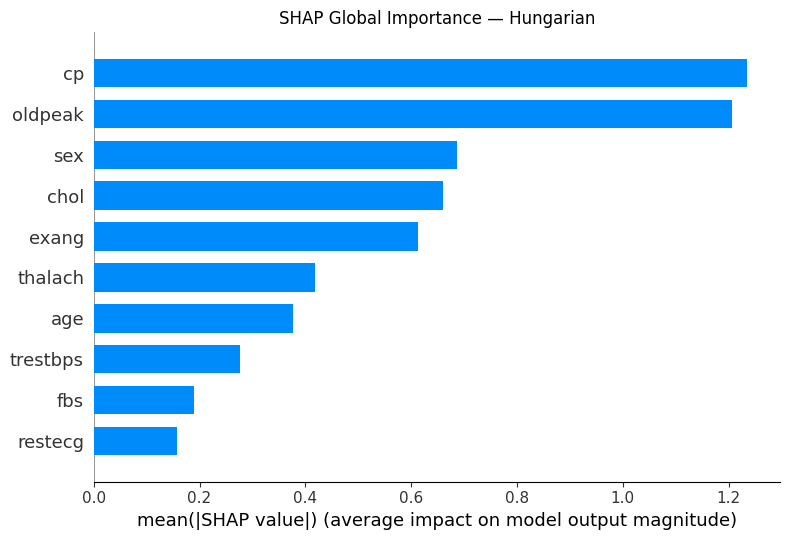

  Saved: shap_bar_Hungarian.png


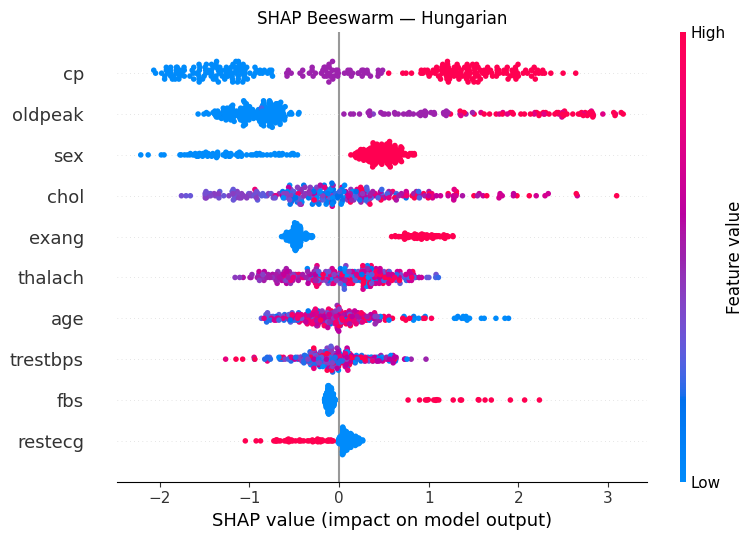

  Saved: shap_beeswarm_Hungarian.png

  Top 10 features by mean absolute SHAP value:
 feature  mean_shap
      cp   1.235336
 oldpeak   1.206537
     sex   0.685742
    chol   0.659514
   exang   0.612944
 thalach   0.419016
     age   0.377477
trestbps   0.276546
     fbs   0.188597
 restecg   0.157739


In [ ]:

url_hun = ('https://archive.ics.uci.edu/ml/machine-learning-databases/'
           'heart-disease/processed.hungarian.data')

cols = ['age','sex','cp','trestbps','chol','fbs','restecg',
        'thalach','exang','oldpeak','slope','ca','thal','target']

df_hun = pd.read_csv(url_hun, names=cols, na_values='?')
for c in cols:
    df_hun[c] = pd.to_numeric(df_hun[c], errors='coerce')

miss_rate = df_hun.isnull().mean()
drop_cols = miss_rate[miss_rate > 0.9].index.tolist()
if drop_cols:
    print(f'Columns removed (>90% missing values): {drop_cols}')
    df_hun = df_hun.drop(columns=drop_cols)

summary_hungarian = evaluate_dataset(df_hun, 'target', 'Hungarian')

## 3.2 Dataset 2 — Long Beach VA (UCI)


Columns removed (>90% missing values): ['ca']

  DATASET: Long Beach VA
  Records       : 200
  Initial features   : 12
  Class distribution: {1: 149, 0: 51}
  Imbalance ratio    : 2.92:1 | SMOTE: No

  Nested 5-Fold CV — Baseline [Bayesian Optimization] [Long Beach VA]
  Model                       Acc     ±     Prec      Rec       F1      AUC
  ────────────────────────────────────────────────────────────────────────
  SVM                      75.50% ±2.45   75.29%  100.00%   85.89% ±1.34   69.87%
  Naive Bayes              74.00% ±6.04   79.21%   88.55%   83.50% ±3.96   70.99%
  Random Forest            74.50% ±1.00   75.03%   98.67%   85.21% ±0.61   69.47%
  J48 (DecTree)            75.00% ±2.74   77.40%   93.95%   84.85% ±1.62   56.59%
  Logistic Regression      74.50% ±1.00   74.76%   99.33%   85.30% ±0.64   70.04%
  XGBoost                  74.50% ±1.00   74.76%   99.33%   85.30% ±0.64   67.38%
  LightGBM                 75.00% ±0.00   74.87%  100.00%   85.63% ±0.17   70.37%
  KN

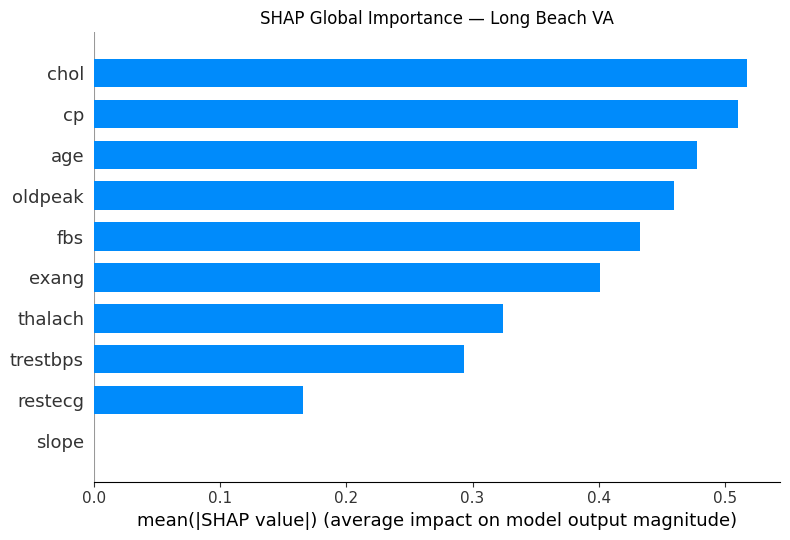

  Saved: shap_bar_Long_Beach_VA.png


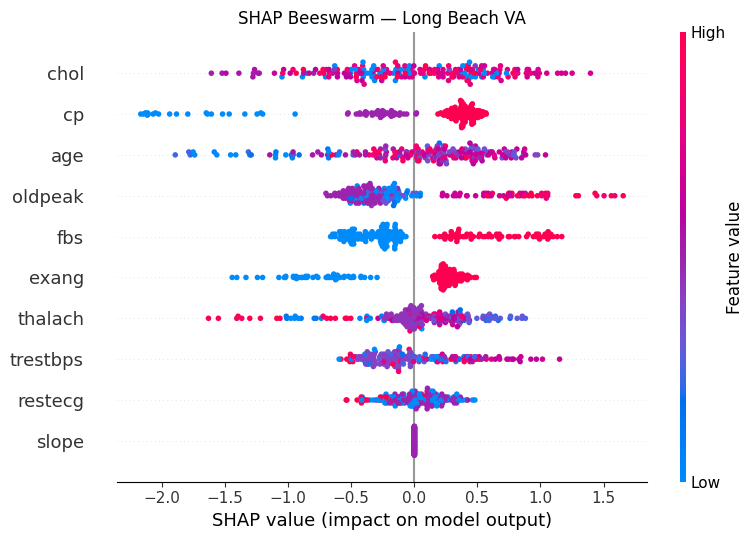

  Saved: shap_beeswarm_Long_Beach_VA.png

  Top 10 features by mean absolute SHAP value:
 feature  mean_shap
    chol   0.517545
      cp   0.510082
     age   0.477979
 oldpeak   0.459403
     fbs   0.432702
   exang   0.401209
 thalach   0.324063
trestbps   0.293032
 restecg   0.165620
     sex   0.000000


In [ ]:

url_va = ('https://archive.ics.uci.edu/ml/machine-learning-databases/'
          'heart-disease/processed.va.data')

cols = ['age','sex','cp','trestbps','chol','fbs','restecg',
        'thalach','exang','oldpeak','slope','ca','thal','target']

df_va = pd.read_csv(url_va, names=cols, na_values='?')
for c in cols:
    df_va[c] = pd.to_numeric(df_va[c], errors='coerce')

miss_rate = df_va.isnull().mean()
drop_cols = miss_rate[miss_rate > 0.9].index.tolist()
if drop_cols:
    print(f'Columns removed (>90% missing values): {drop_cols}')
    df_va = df_va.drop(columns=drop_cols)

summary_va = evaluate_dataset(df_va, 'target', 'Long Beach VA')

## 3.3 Dataset 3 — Statlog Heart (UCI)



  DATASET: Statlog Heart
  Records       : 270
  Initial features   : 13
  Class distribution: {1: 120, 0: 150}
  Imbalance ratio    : 1.25:1 | SMOTE: No

  Nested 5-Fold CV — Baseline [Bayesian Optimization] [Statlog Heart]
  Model                       Acc     ±     Prec      Rec       F1      AUC
  ────────────────────────────────────────────────────────────────────────
  SVM                      85.19% ±6.42   85.97%   79.17%   82.29% ±8.34   90.61%
  Naive Bayes              84.07% ±4.32   83.45%   80.00%   81.54% ±5.64   89.44%
  Random Forest            81.48% ±5.24   82.50%   74.17%   77.95% ±6.59   88.63%
  J48 (DecTree)            74.07% ±6.83   74.82%   64.17%   68.75% ±7.62   75.03%
  Logistic Regression      84.07% ±6.69   84.39%   78.33%   81.03% ±8.73   90.36%
  XGBoost                  81.11% ±5.02   82.38%   73.33%   77.35% ±6.62   87.53%
  LightGBM                 82.22% ±4.16   82.31%   77.50%   79.40% ±5.03   87.81%
  KNN                      82.59% ±6.99   82.12% 

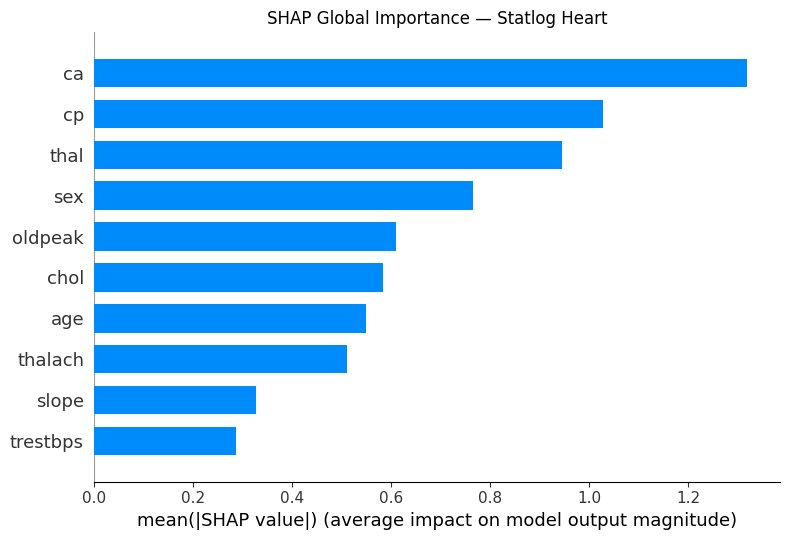

  Saved: shap_bar_Statlog_Heart.png


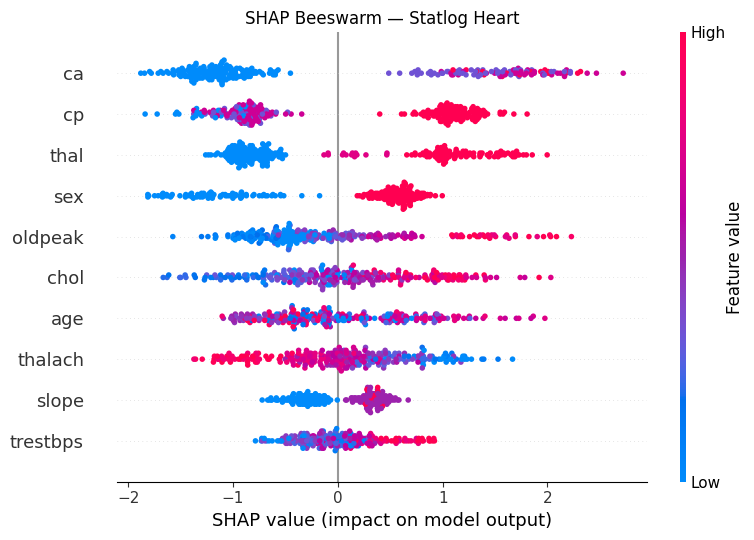

  Saved: shap_beeswarm_Statlog_Heart.png

  Top 10 features by mean absolute SHAP value:
 feature  mean_shap
      ca   1.319849
      cp   1.028363
    thal   0.944753
     sex   0.765631
 oldpeak   0.609913
    chol   0.584277
     age   0.549522
 thalach   0.510877
   slope   0.326788
trestbps   0.286304


In [ ]:

url_stat = ('https://archive.ics.uci.edu/ml/machine-learning-databases/'
            'statlog/heart/heart.dat')

cols = ['age','sex','cp','trestbps','chol','fbs','restecg',
        'thalach','exang','oldpeak','slope','ca','thal','target']

df_stat = pd.read_csv(url_stat, sep=r'\s+', names=cols, header=None)
df_stat['target'] = (df_stat['target'] == 2).astype(int)

summary_statlog = evaluate_dataset(df_stat, 'target', 'Statlog Heart', binarize=False)

## 3.4 Dataset 4 — Heart Failure Clinical Records (UCI)


Dataset shape: (299, 13)
DEATH_EVENT distribution: Counter({0: 203, 1: 96})

  DATASET: Heart Failure Clinical
  Records       : 299
  Initial features   : 12
  Class distribution: {1: 96, 0: 203}
  Imbalance ratio    : 2.11:1 | SMOTE: No

  Nested 5-Fold CV — Baseline [Bayesian Optimization] [Heart Failure Clinical]
  Model                       Acc     ±     Prec      Rec       F1      AUC
  ────────────────────────────────────────────────────────────────────────
  SVM                      82.26% ±2.61   78.13%   62.42%   69.22% ±5.01   86.64%
  Naive Bayes              77.59% ±3.29   74.43%   46.89%   57.45% ±4.98   85.15%
  Random Forest            83.26% ±4.56   76.64%   68.68%   72.13% ±8.80   89.82%
  J48 (DecTree)            80.94% ±2.48   73.31%   65.42%   68.05% ±7.18   85.44%
  Logistic Regression      83.59% ±4.65   78.61%   67.74%   72.55% ±7.91   87.54%
  XGBoost                  82.94% ±4.13   75.76%   68.74%   71.86% ±7.86   90.31%
  LightGBM                 84.94% ±2.4

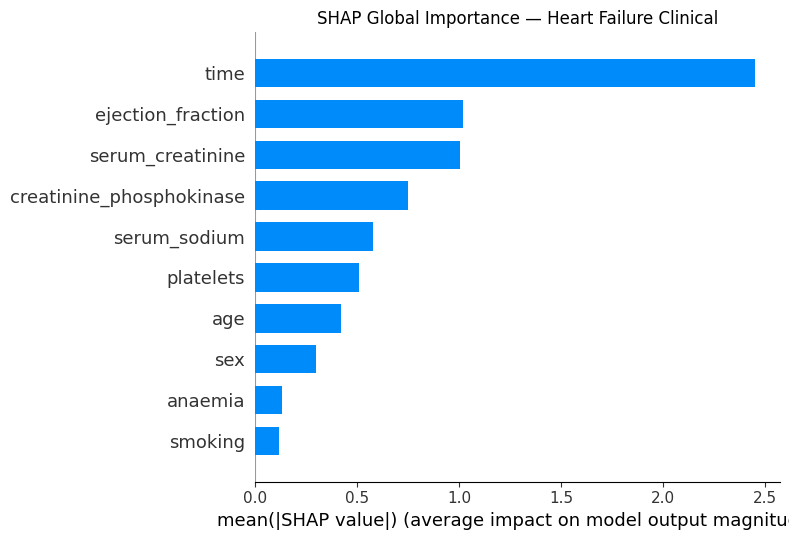

  Saved: shap_bar_Heart_Failure_Clinical.png


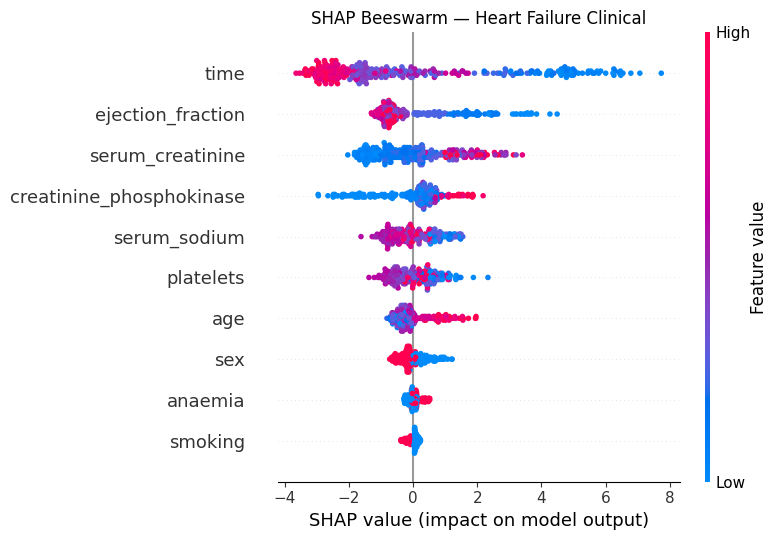

  Saved: shap_beeswarm_Heart_Failure_Clinical.png

  Top 10 features by mean absolute SHAP value:
                 feature  mean_shap
                    time   2.450310
       ejection_fraction   1.019662
        serum_creatinine   1.005214
creatinine_phosphokinase   0.749613
            serum_sodium   0.580999
               platelets   0.509756
                     age   0.421540
                     sex   0.300191
                 anaemia   0.131374
                 smoking   0.116840


In [ ]:

url_hf = ('https://archive.ics.uci.edu/ml/machine-learning-databases/'
          '00519/heart_failure_clinical_records_dataset.csv')

df_hf = pd.read_csv(url_hf)
print('Dataset shape:', df_hf.shape)
print(f'DEATH_EVENT distribution: {Counter(df_hf["DEATH_EVENT"])}')

summary_hf = evaluate_dataset(df_hf, 'DEATH_EVENT', 'Heart Failure Clinical', binarize=False)

## 3.5 Dataset 5 — Cleveland (UCI)



  DATASET: Cleveland
  Records       : 303
  Initial features   : 13
  Class distribution: {0: 164, 1: 139}
  Imbalance ratio    : 1.18:1 | SMOTE: No

  Nested 5-Fold CV — Baseline [Bayesian Optimization] [Cleveland]
  Model                       Acc     ±     Prec      Rec       F1      AUC
  ────────────────────────────────────────────────────────────────────────
  SVM                      84.48% ±3.45   85.58%   79.84%   82.37% ±4.27   91.14%
  Naive Bayes              85.46% ±4.03   86.32%   82.01%   83.85% ±4.16   90.22%
  Random Forest            84.15% ±3.44   87.56%   76.22%   81.43% ±4.36   91.41%
  J48 (DecTree)            77.85% ±4.80   77.29%   74.07%   75.48% ±4.91   77.90%
  Logistic Regression      84.14% ±4.04   85.98%   78.41%   81.78% ±4.89   91.19%
  XGBoost                  81.83% ±5.18   81.93%   78.39%   79.87% ±5.62   88.38%
  LightGBM                 82.17% ±1.99   83.56%   76.24%   79.60% ±2.84   90.60%
  KNN                      82.83% ±2.77   84.10%   77.70%

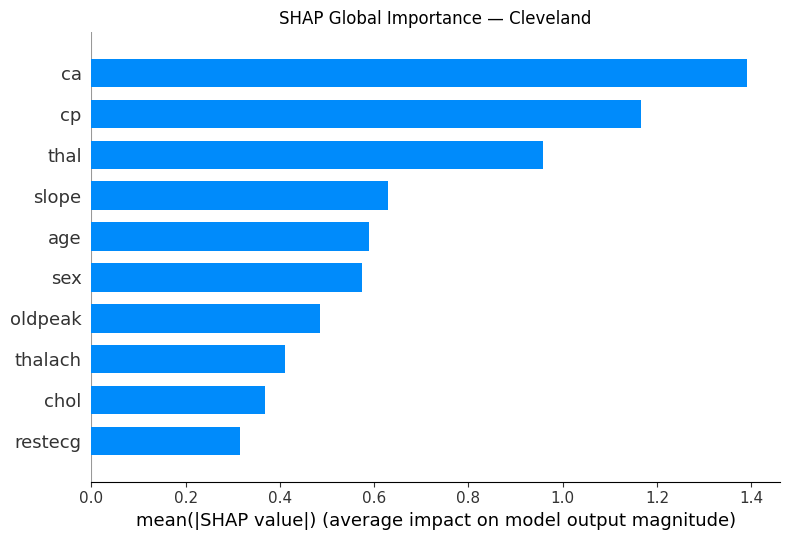

  Saved: shap_bar_Cleveland.png


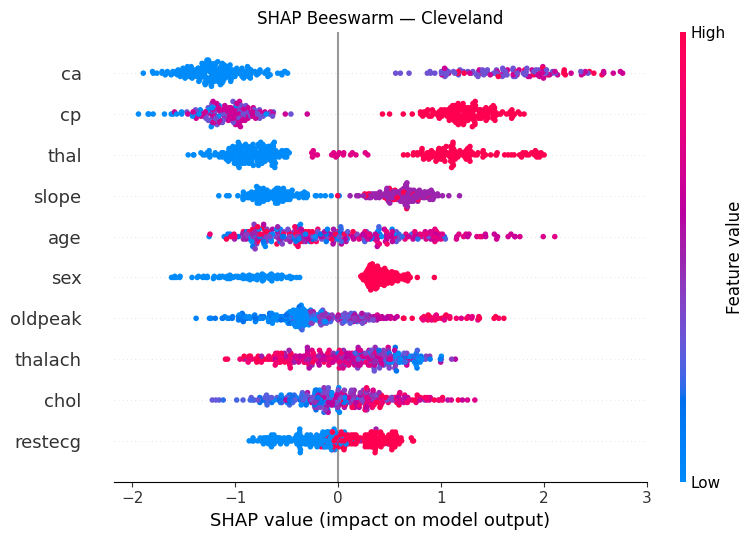

  Saved: shap_beeswarm_Cleveland.png

  Top 10 features by mean absolute SHAP value:
feature  mean_shap
     ca   1.391211
     cp   1.166260
   thal   0.957869
  slope   0.629362
    age   0.589727
    sex   0.574344
oldpeak   0.484544
thalach   0.410322
   chol   0.369083
restecg   0.316086


In [ ]:

url_cleveland = ('https://archive.ics.uci.edu/ml/machine-learning-databases/'
                 'heart-disease/processed.cleveland.data')

cols = ['age','sex','cp','trestbps','chol','fbs','restecg',
        'thalach','exang','oldpeak','slope','ca','thal','target']

df_cleveland = pd.read_csv(url_cleveland, names=cols, na_values='?')
for c in cols:
    df_cleveland[c] = pd.to_numeric(df_cleveland[c], errors='coerce')

miss_rate = df_cleveland.isnull().mean()
drop_cols = miss_rate[miss_rate > 0.9].index.tolist()
if drop_cols:
    print(f'Columns removed (>90% missing values): {drop_cols}')
    df_cleveland = df_cleveland.drop(columns=drop_cols)

summary_cleveland = evaluate_dataset(df_cleveland, 'target', 'Cleveland')

# 4. Results Summary and Comparison


## 4.1 Cross-Dataset F1-Score Summary


In [ ]:

all_summaries = [
    summary_hungarian,
    summary_va,
    summary_statlog,
    summary_hf,
    summary_cleveland,
]

model_order = ['SVM', 'Naive Bayes', 'Random Forest', 'J48 (DecTree)',
               'Logistic Regression', 'XGBoost', 'LightGBM', 'KNN',
               'Soft Voting Ensemble']

f1_table = pd.DataFrame(index=model_order,
                        columns=[s['dataset'] for s in all_summaries],
                        dtype=float)
for s in all_summaries:
    for m in model_order:
        if m in s['results']:
            f1_table.loc[m, s['dataset']] = s['results'][m]['f1'].mean() * 100

print('Mean F1-Score (%) — Nested 5-Fold CV\n')
print(f1_table.round(2).to_string())

print('\n\nBest model per dataset based on F1-Score:')
for ds in f1_table.columns:
    best_m = f1_table[ds].idxmax()
    best_v = f1_table[ds].max()
    sv_v   = f1_table.loc['Soft Voting Ensemble', ds]
    delta  = sv_v - best_v if best_m != 'Soft Voting Ensemble' else 0
    flag   = f'  (Soft Voting: {sv_v:.2f}%, difference {delta:+.2f}%)' if best_m != 'Soft Voting Ensemble' else ''
    print(f'  {ds:<25}: {best_m:<22} = {best_v:.2f}%{flag}')

Mean F1-Score (%) — Nested 5-Fold CV

                      Hungarian  Long Beach VA  Statlog Heart  Heart Failure Clinical  Cleveland
SVM                       76.17          85.89          82.29                   69.22      82.37
Naive Bayes               71.87          83.50          81.54                   57.45      83.85
Random Forest             75.34          85.21          77.95                   72.13      81.43
J48 (DecTree)             70.17          84.85          68.75                   68.05      75.48
Logistic Regression       76.15          85.30          81.03                   72.55      81.78
XGBoost                   71.11          85.30          77.35                   71.86      79.87
LightGBM                  71.88          85.63          79.40                   74.61      79.60
KNN                       74.01          86.66          79.54                   40.98      80.59
Soft Voting Ensemble      76.36          85.80          80.77                   74.07    

## 4.2 Cross-Dataset Accuracy Summary


In [ ]:

acc_table = pd.DataFrame(index=model_order,
                         columns=[s['dataset'] for s in all_summaries],
                         dtype=float)
for s in all_summaries:
    for m in model_order:
        if m in s['results']:
            acc_table.loc[m, s['dataset']] = s['results'][m]['acc'].mean() * 100

print('Mean Accuracy (%) — Nested 5-Fold CV\n')
print(acc_table.round(2).to_string())

Mean Accuracy (%) — Nested 5-Fold CV

                      Hungarian  Long Beach VA  Statlog Heart  Heart Failure Clinical  Cleveland
SVM                       84.37           75.5          85.19                   82.26      84.48
Naive Bayes               75.55           74.0          84.07                   77.59      85.46
Random Forest             83.02           74.5          81.48                   83.26      84.15
J48 (DecTree)             79.25           75.0          74.07                   80.94      77.85
Logistic Regression       84.03           74.5          84.07                   83.59      84.14
XGBoost                   80.29           74.5          81.11                   82.94      81.83
LightGBM                  80.97           75.0          82.22                   84.94      82.17
KNN                       82.99           78.0          82.59                   70.90      82.83
Soft Voting Ensemble      84.38           75.5          83.70                   84.60    